In [206]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


# **Linguistic Pipeline in action 🦐**

Text_01_1115, St01_d **Il contadino astrologo**

In [178]:
with open ("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\data\\texts_1115\\01_1115.txt", 'r', encoding="utf-8")as infile:
    text = infile.read()

print(text[:500])

Il contadino astrologo.
Un Re aveva perduto un anello prezioso. Cerca qua, cerca là, non si trova. Mise fuori un bando che
se un astrologo gli sa dire dov'è, lo fa ricco per tutta la vita. C'era un contadino senza un soldo, che non sapeva né leggere né scrivere, e si chiamava Gàmbara. "Sarà tanto difficile far l'astrologo? - si disse. – Mi ci voglio provare". E andò dal Re che lo prese in parola, e lo chiuse a studiare in una stanza. Dove c'erano solo un letto e un tavolo con un gran libraccio d


## **First Step**
*.py file* = `nlp_pipeline/processor.py`

- tokenization
- mwe
- lemmatization
- PoS
- Deapparse/Consituency
- **Zipf's frequency**
- **Type of words (*content, function*)**
- AoA

- **Statistics of texts**

In [179]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df.head(10)

,token_id,sentence_ids,tokens_no_punct,lemma_no_punct,PoS,depparse,head,constituency,AoA(m+sd),Zipf_freq,type_of_words
0,1,0,il,il,DET,det,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"7,039560886",function
1,2,0,contadino,contadino,NOUN,root,ROOT,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"3,787520326",content
2,3,0,astrologo,astrologo,ADJ,amod,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"2,502677091",content
3,4,1,un,uno,DET,det,Re,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"7,065833912",function
4,5,1,re,re,NOUN,nsubj,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,4.24 ± 1.76,"5,011715611",content
5,6,1,aveva,avere,AUX,aux,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"5,632280537",function
6,7,1,perduto,perdere,VERB,root,ROOT,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,078821718",content
7,8,1,un,uno,DET,det,anello,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"7,065833912",function
8,9,1,anello,anello,NOUN,obj,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,631517492",content
9,10,1,prezioso,prezioso,ADJ,amod,anello,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,02438909",content


## **Statistics on the text**
*.py file* = `nlp_pipeline/processor.py`


In [180]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\summary_all_texts.csv")

df.head(1)

,text_id,num_tokens,num_sentences,num_types,TTR,TTR_lemmas,avg_sentence_length,Zipf_mean,percent_rare_words,Gulpease_index,num_function_words,num_content_words,num_verbs,num_adjectives,num_nouns,top_lemmas,top_bigrams
0,01_1115,519,41,261,0.503,0.374,15.24,5.29,12.75,70.37,287 (55.3%),229 (44.1%),102 (19.7%),22 (4.2%),105 (20.2%),"['il (7.1%)', 'e (5.2%)', 'essere (4.4%)', 'un...","['l anello (0.8%)', 'e si (0.6%)', 'l astrolog..."



# <span style="color:#C8C8FF">**PREDICTORS**</span>
1. **Word Frequency**
2. **Lexical Surprisal**
3. **Lexical Entropy**
4. **Semantic Dissimilarity**
---
5. PoS Surprisal🤔


## **1. Word Frequency**

*.py file* = `nlp_pipeline/processor.py`

The **Zipf scale**: a standardized frequency measure.
To make the word frequency effect easier to understand, one need a scale with the following properties:
- it should be a logarithmic scale
- it should have relatively few points, without negative values
- the middle of the scale should separate the low-frequency words from the high-frequency words
- the scale should have a straightforward unit.

The Zipf scale is a **logarithmic scale** and goes from 1 to 7. 

**Zipf (w) = log10(fpmw) +3** or **Zipf(w) = log10(fpbw)**

*fpmw* = frequency per million words\
*fpbw* = frequency per billion words


[van Heuven WJ, Mandera P, Keuleers E, Brysbaert M. *SUBTLEX-UK: a new and improved word frequency database for British English*. Q J Exp Psychol (Hove). 2014;67(6):1176-90. doi: 10.1080/17470218.2013.850521. Epub 2014 Jan 13. PMID: 24417251]

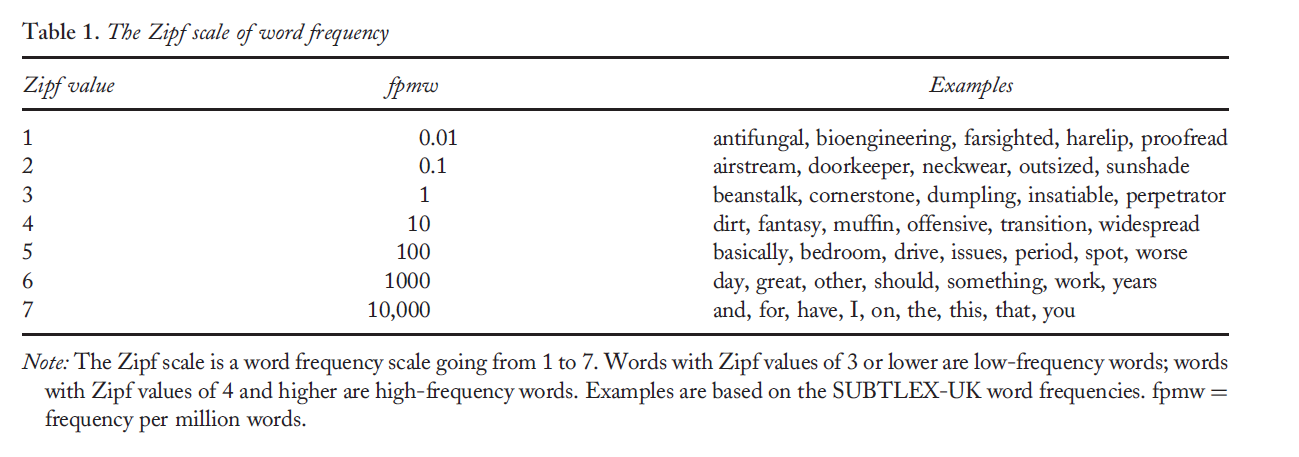

In [181]:
from IPython.display import Image
Image("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\doc\\Zipffreq.png")

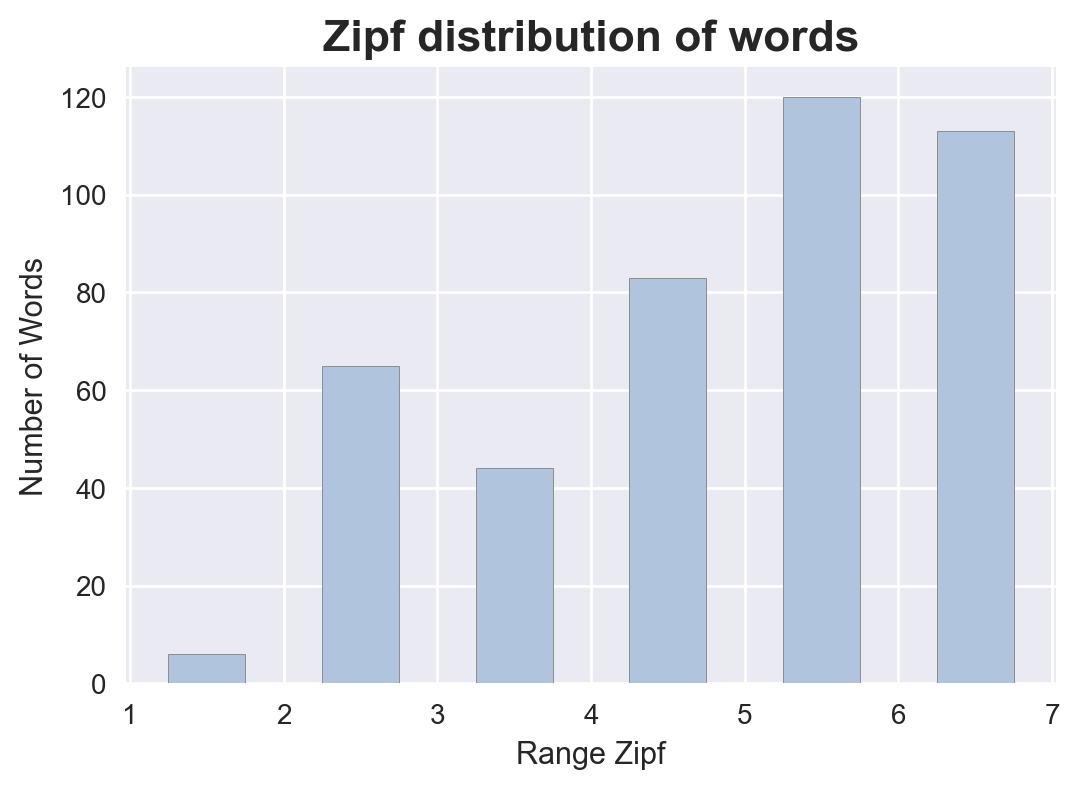

In [182]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df["Zipf_freq"] = df["Zipf_freq"].str.replace(',', '.').astype(float)

# Definizione dei bin
bins = [1, 2, 3, 4, 5, 6, 7, float("inf")]

plt.figure(figsize=(6, 4))
plt.style.use("seaborn-v0_8")
plt.hist(df["Zipf_freq"], bins=bins, color="lightsteelblue", rwidth=0.5, edgecolor="gray")
plt.xlabel("Range Zipf")
plt.ylabel("Number of Words")
plt.title("Zipf distribution of words", fontsize=16, fontweight="bold")
plt.show()


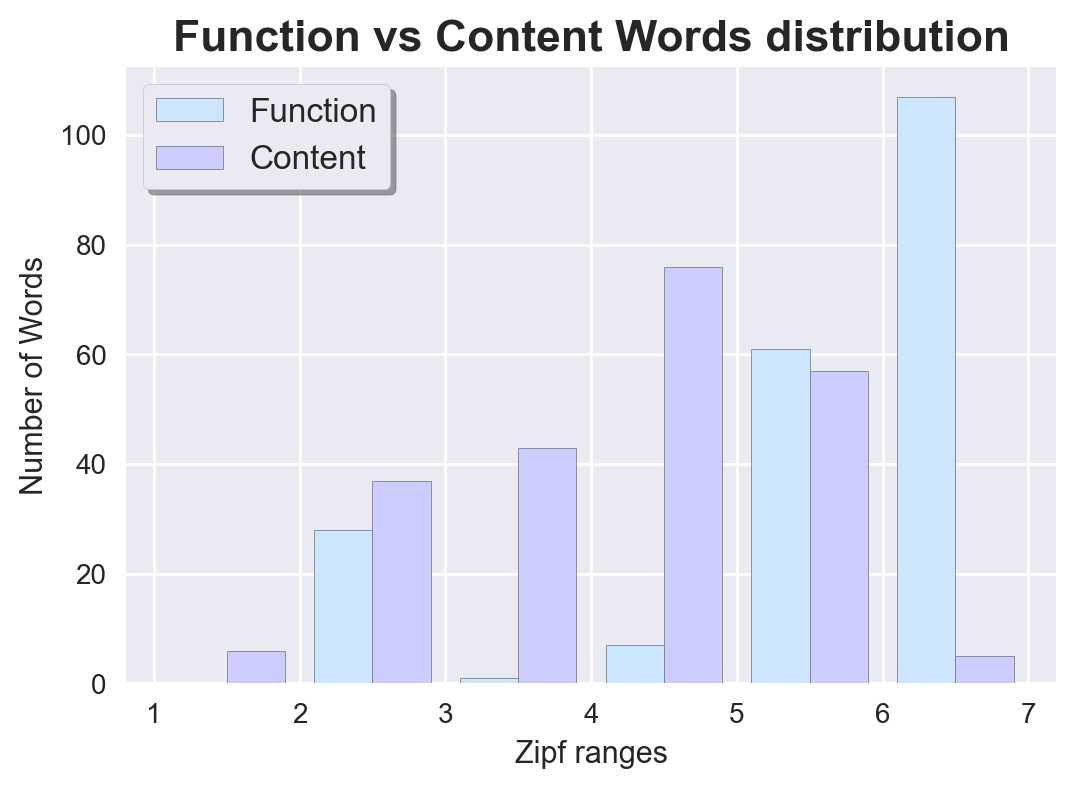

In [183]:
df_funzione = df[df["type_of_words"] == "function"]
df_contenuto = df[df["type_of_words"] == "content"]
plt.figure(figsize=(6, 4))

plt.hist(
    [df_funzione["Zipf_freq"], df_contenuto["Zipf_freq"]],
    bins=bins,
    color=[(204/255, 230/255, 255/255), (204/255, 204/255, 255/255)],
    label=["Function", "Content"], edgecolor="gray")

plt.xlabel("Zipf ranges")
plt.ylabel("Number of Words")
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.title("Function vs Content Words distribution", fontsize=16, fontweight="bold")
plt.show()


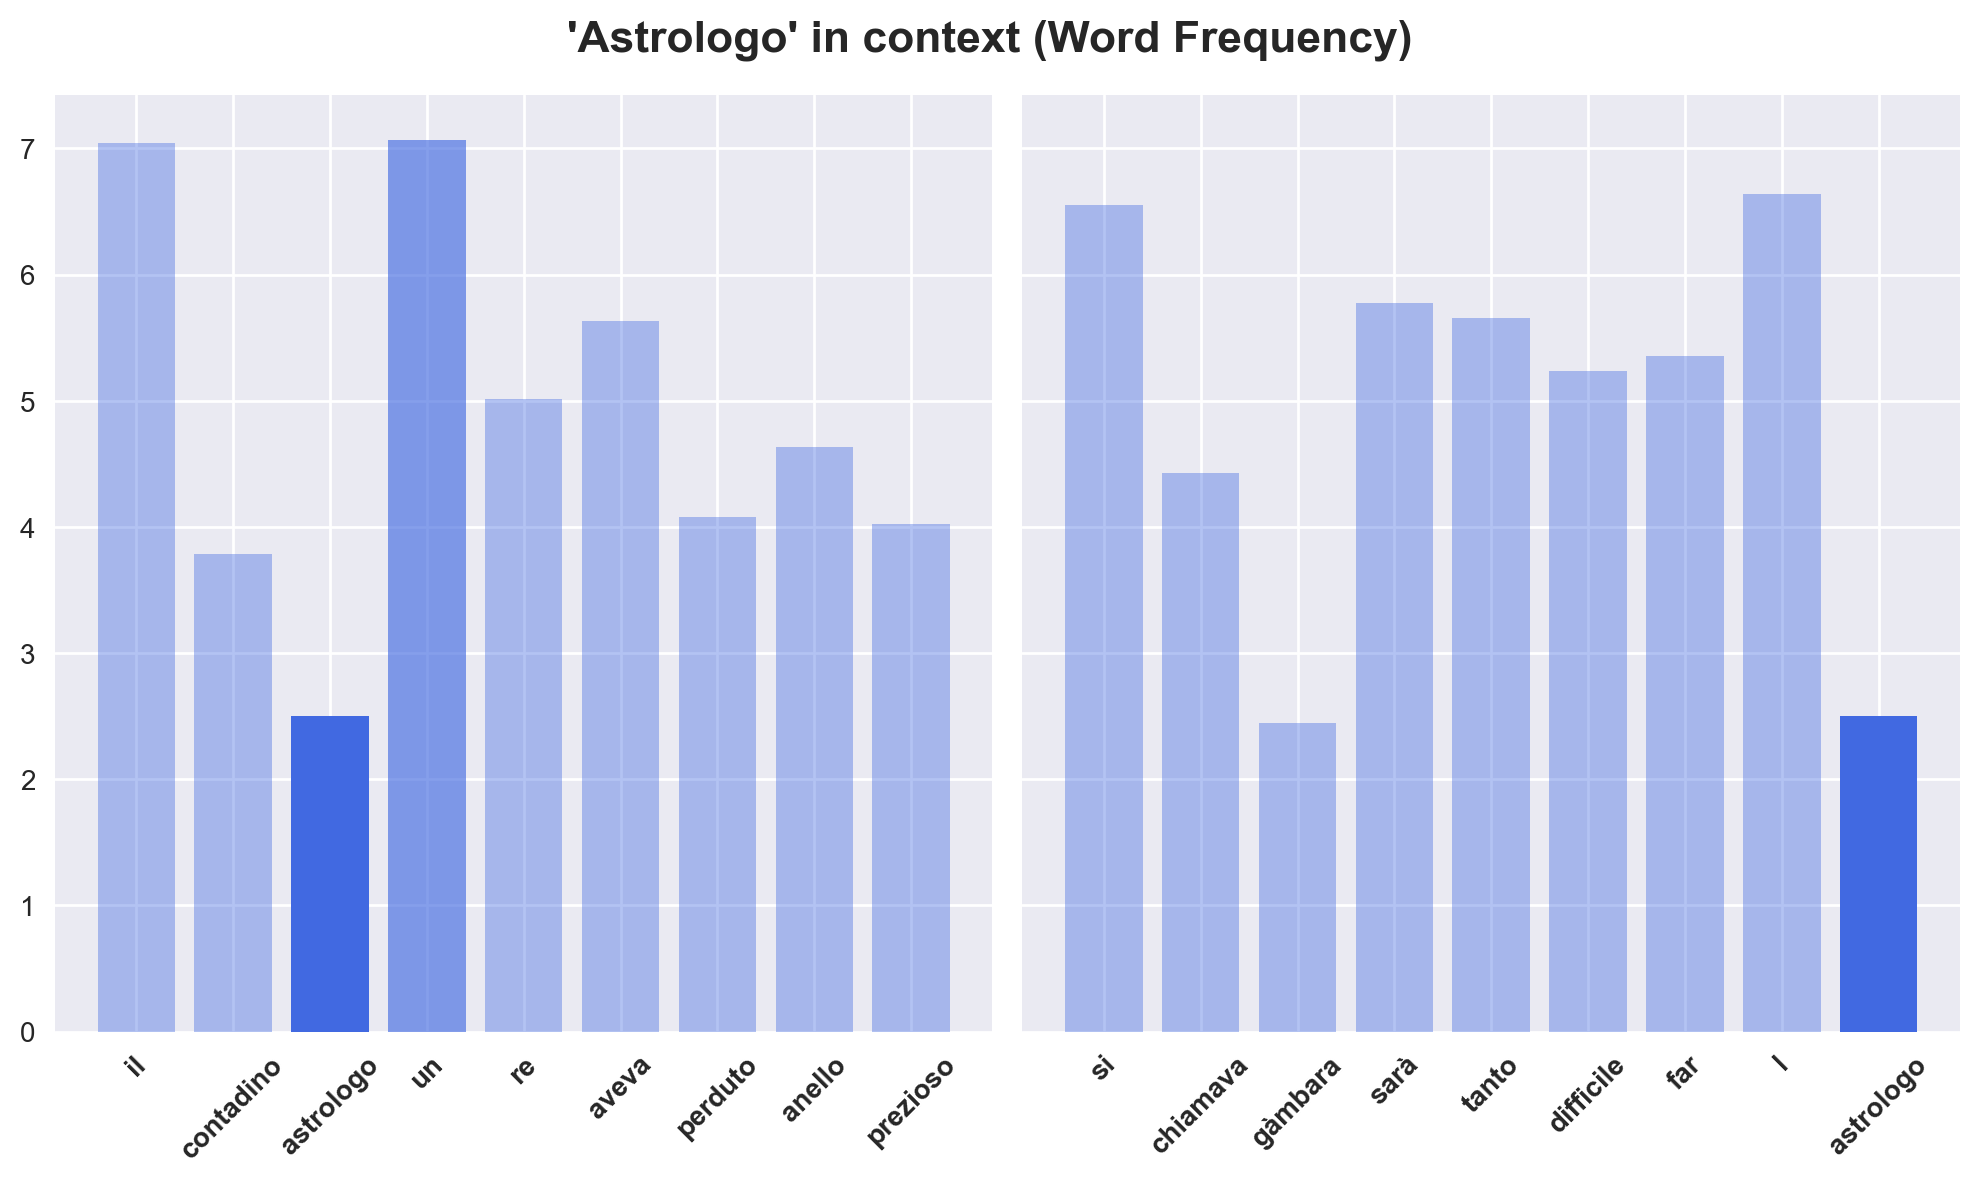

In [186]:
plt.style.use("seaborn-v0_8")
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

highlight=["astrologo"]
base_color = mcolors.to_rgba("royalblue")
words1 = df["tokens_no_punct"][:10]
colors1 = [
    (base_color[0], base_color[1], base_color[2], 1.0 if w in highlight else 0.4)
    for w in words1
]

axs[0].bar(words1, df["Zipf_freq"][:10], color=colors1)

axs[0].tick_params(axis='x', labelrotation=45)
for tick in axs[0].get_xticklabels():
    tick.set_fontweight("bold")

words2 = df["tokens_no_punct"][52:61]
colors2 = [
    (base_color[0], base_color[1], base_color[2], 1.0 if w in highlight else 0.4)
    for w in words2
]

axs[1].bar(words2, df["Zipf_freq"][52:61], color=colors2)
axs[1].tick_params(axis='x', labelrotation=45)
for tick in axs[1].get_xticklabels():
    tick.set_fontweight("bold")

fig.suptitle("'Astrologo' in context (Word Frequency)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## **2. Lexical Surprisal** & **3. Lexical Entropy**

*.py file* = `nlp_pipeline/surprisal_entropy.py`

The **surprisal**, also referred to as **self-information** or information content, quantifies the information gain that an upcoming word generates with respect to the prior sequence of words.It can be related to how unexpected a word is given the previous words in the sentence. 

**Surprisal(Wx) = -log2(P(Wx|W1, ..., WX-1))**

--- 

The **entropy** of the prediction of the x*th* word (Wx) is the uncertainty for predicting the word *Wx* from the context *(W1, ..., WX-1)* and is computed as the sum of the conditional probabilisties for each possibile word *Wk*, weighted by the logarithm of this probability.

**Entropy(Wx)= sum(P(Wk|W1, ..., WX-1)log2[P(Wk|W1, ..., WX-1)])**


### **What we need?**
We need **conditional probabilities**
These probabilities are computed using the **GePpeTto** model, a **decoder-only** transformer. 
The key feature of a decoder-only architecture in NLP is that it is **auto-regressive**: when processing a sequence of tokens, the model can only attend to the tokens it has already generated, and it predicts the next token based on **probabilistic calculations**. 

What better opportunity do we have to ‘steal’ some of the model’s statistical knowledge of Italian from a given text?

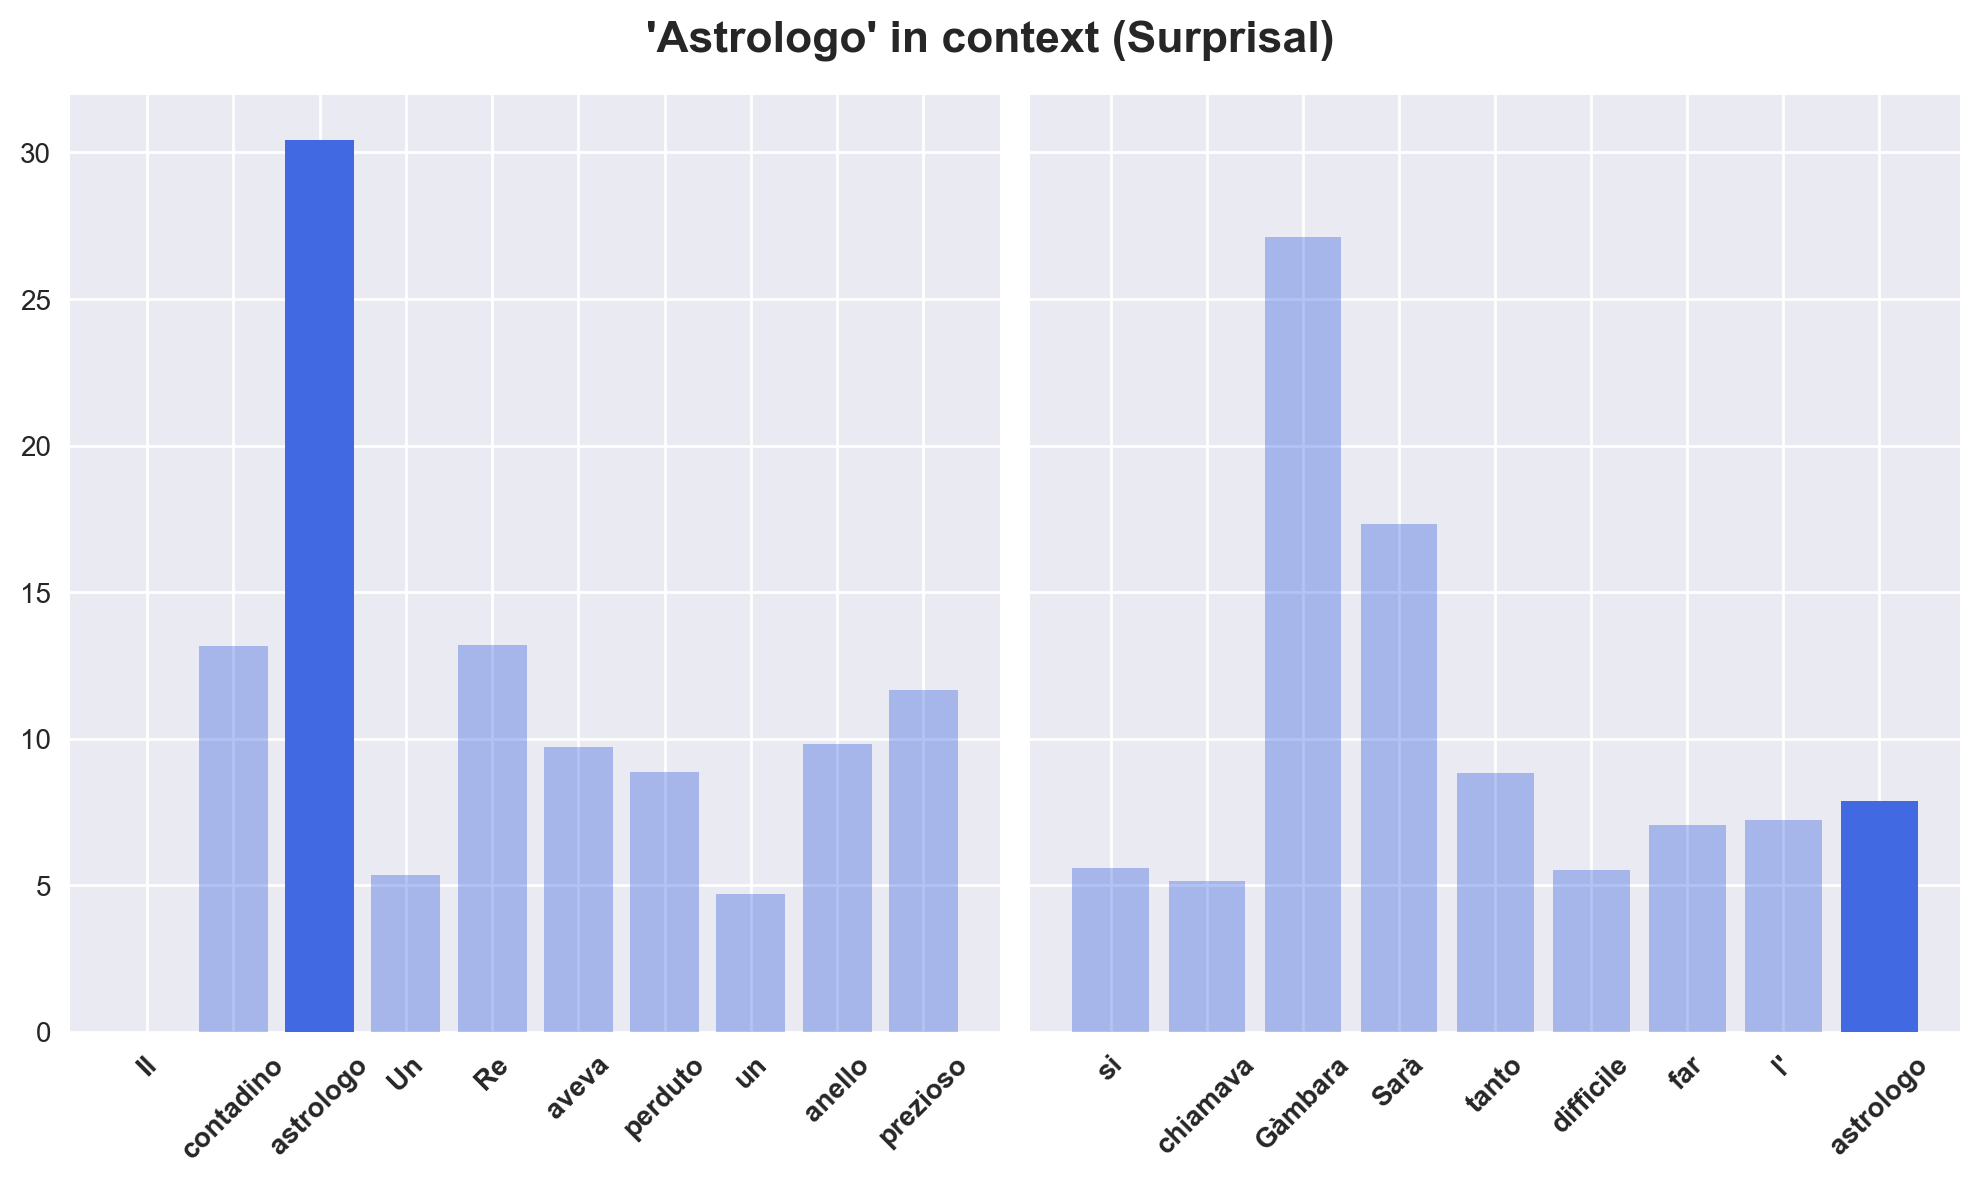

In [ ]:
df= pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\suprisal_entropy01_1115.csv")
df.head()

plt.style.use("seaborn-v0_8")
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

highlight=["astrologo"]
base_color = mcolors.to_rgba("royalblue")
words1 = df["word"][:10]
colors1 = [
    (base_color[0], base_color[1], base_color[2], 1.0 if w in highlight else 0.4)
    for w in words1
]

axs[0].bar(words1, df["surprisal"][:10], color=colors1)

axs[0].tick_params(axis='x', labelrotation=45)
for tick in axs[0].get_xticklabels():
    tick.set_fontweight("bold")
words2 = df["word"][52:61]

colors2 = [
    (base_color[0], base_color[1], base_color[2], 1.0 if w in highlight else 0.4)
    for w in words2
]

axs[1].bar(words2, df["surprisal"][52:61], color=colors2)
axs[1].tick_params(axis='x', labelrotation=45)
for tick in axs[1].get_xticklabels():
    tick.set_fontweight("bold")

fig.suptitle("'Astrologo' in context (Surprisal)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## **4. Semantic Dissimilarity**
*.py file* = `nlp_pipeline/semantic_dissimilarity.py`

The idea behind **contextual semantics** is that words that share **common context** in a very large corpus of text are converted to vectors that are located in close proximity to one another in this high-dimensional space.

Humans can easily recognize 'words', but how can we make them understandable to machines? Machines only understand numbers:

→ we need to tranformes words in numbers (word vectors)
At the beginning, these numbers might be arbitrary, but now we use **word embeddings**, which are word vectors that capture some semantic information, derived from the context in which words appear.

--- 

**Semantic dissimilarity** is more a measure of local word context and not a direct measure of semantics per se, the vector associated with each word can be used as a proxy for the word's meaning.

$ \text{semantic\_dissimilarity}(W_x) = 1 - \cos(\vec{W}_x, \vec{Context}) $

The **word embeddings** used here are derived from **UmBERTo**, an Italian BERT-based model. Thanks to its **encoder-only** architecture, UmBERTo is able to observe the entire input sequence, which allows it to generate high-quality semantic representations of words and phrases in Italian.


# <span style="color:#C8C8FF">**CORRELATIONS**</span>


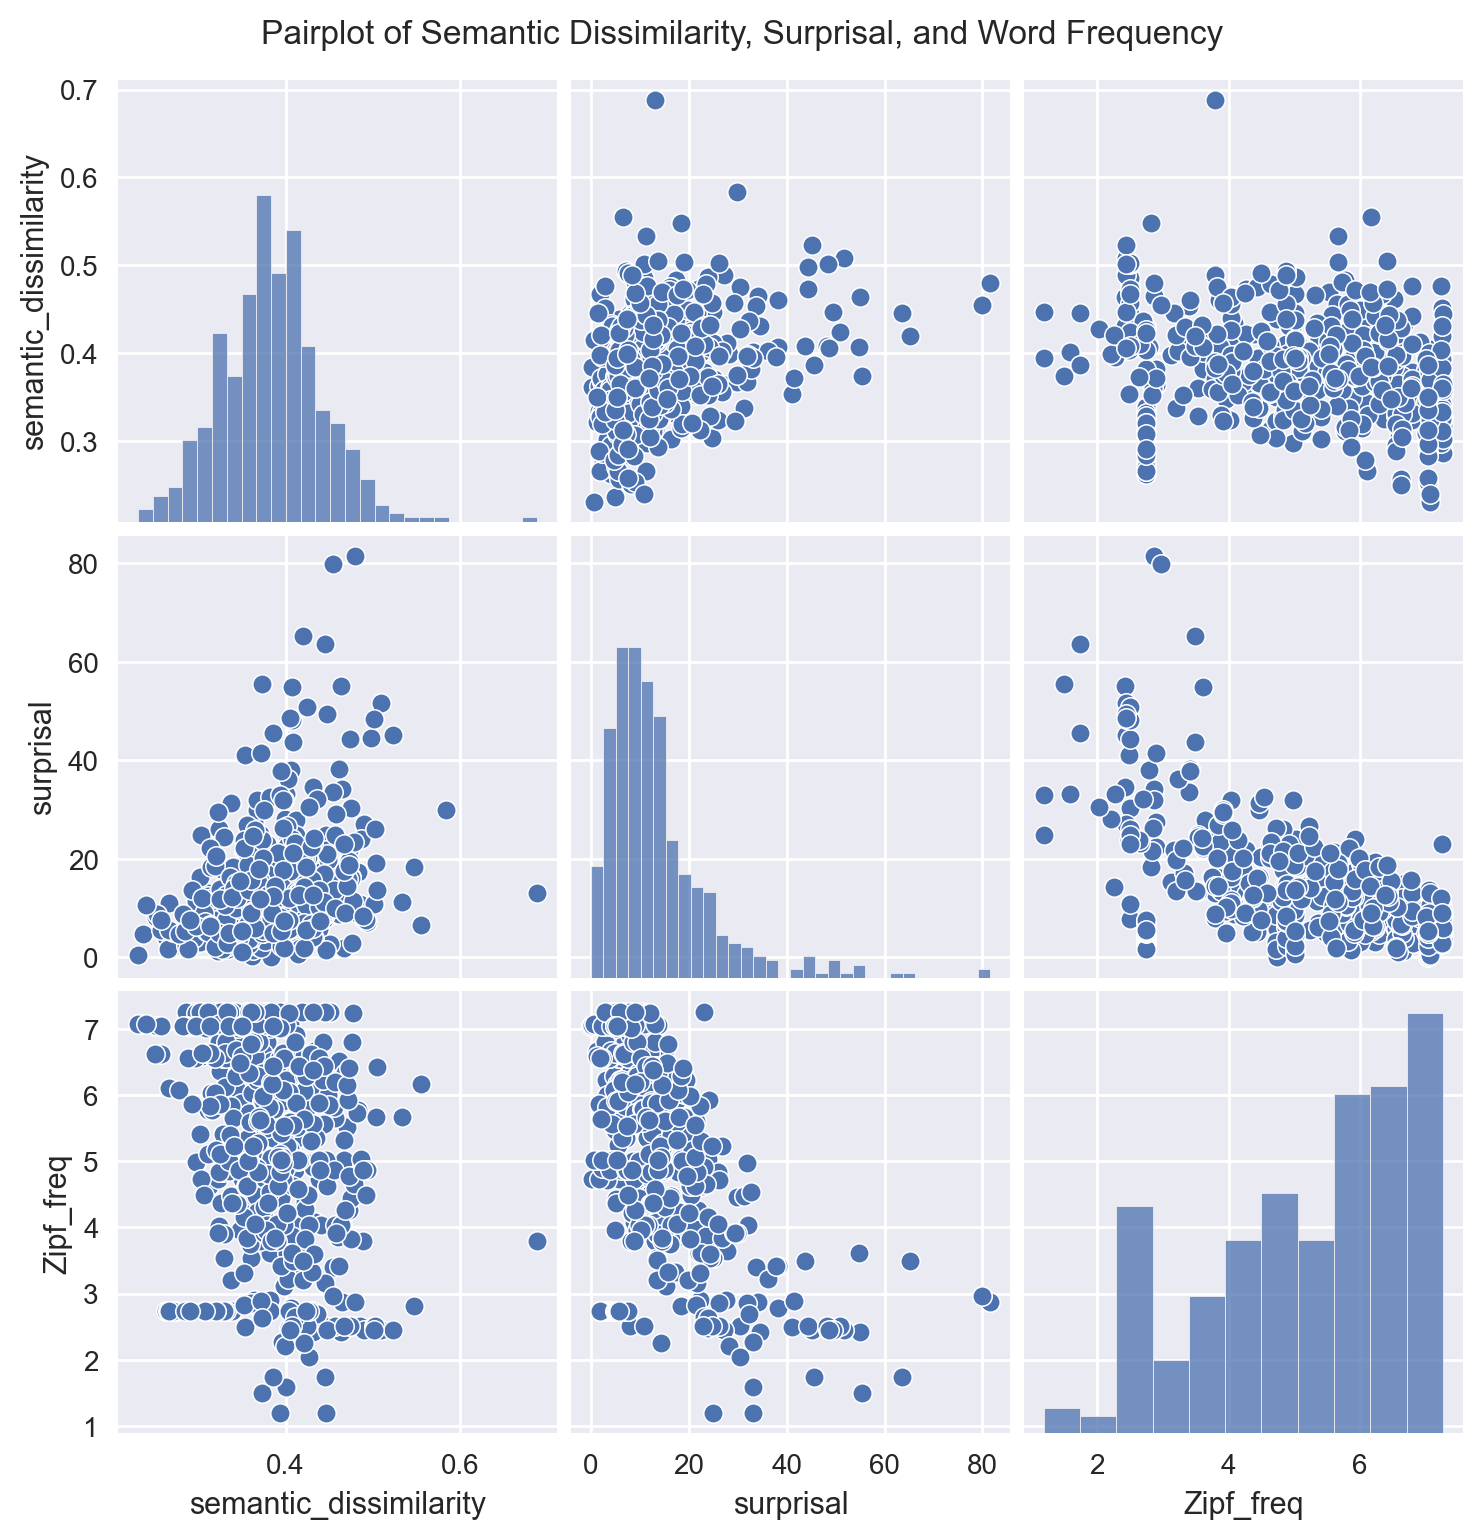

In [212]:
df_wordfreq= pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";")
df_surp= pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\suprisal_entropy01_1115.csv")
df_diss= pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\dissimilarity_01_1115.csv")
df_wordfreq["Zipf_freq"] = df_wordfreq["Zipf_freq"].str.replace(',', '.').astype(float)

df = pd.concat([df_surp["word"], df_wordfreq['Zipf_freq'], df_surp["surprisal"], df_diss['semantic_dissimilarity']], axis=1)

sns.pairplot(df[["semantic_dissimilarity", "surprisal", "Zipf_freq"]])
plt.suptitle("Pairplot of Semantic Dissimilarity, Surprisal, and Word Frequency", y=1.02)
plt.show()

